# 02 — UC2 FedAvg

Train FedAvg (Federated Averaging) across the alpha sweep.
This is the standard FL baseline — full model exchange each round.

Paper reference: McMahan et al. "Communication-Efficient Learning 
of Deep Networks from Decentralized Data" (2017)

In [ ]:
import sys, os
sys.path.append("..")
import UC2Utils as uc2
sys.path.insert(0, uc2.LIB_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from collections import Counter


sys.path.insert(0, uc2.LIB_DIR)

print(f"Device: {uc2.DEFAULT_CONFIG['device']}")

## Configuration

In [28]:
ALPHAS = [0.01,0.1,0.5, 1.0, 5.0, 10.0]
MODEL = "lstm"
RETRAIN = False

OVERRIDES = dict(
    num_glob_iters=200,
    local_epochs=50,
    num_users=20,
    early_stopping_patience=20,
    batch_size=32,
)

## Train FedAvg for Each α

Lower α → more heterogeneous data across users → harder for FedAvg.
We expect degradation at low α since FedAvg assumes roughly IID data.

In [ ]:
import os
 
# --- config: must match what notebook 00 used to generate new partitions ---
NEWPART_SUBDIR = "new_partitions"
NEWPART_SUBDIR2 = "new_partitions_2"
_NP_LOOKBACK = uc2.DEFAULT_CONFIG["lookback"]   # 60
_NP_STEPS    = uc2.DEFAULT_CONFIG["steps"]      # 1
 
# keep handles to the originals so we can toggle / restore
_orig_make_args     = uc2.make_args
_orig_result_exists = uc2.result_exists
_orig_load_result   = uc2.load_result
 
_NEWPART_ON = {"flag": False}
 
 
def _newpart_dataset_path():
    return os.path.join(uc2.DATA_PART, NEWPART_SUBDIR,
                        f"lookback_{_NP_LOOKBACK}", f"steps_{_NP_STEPS}")
 
 
def _redirect_result_path(result_path, algorithm, alpha, model):
    """Force any result path under RESULTS/newpart/ so old results stay intact."""
    base = os.path.join(uc2.RESULTS, "newpart")
    if result_path is None:
        return os.path.join(base, algorithm.lower(), f"alpha_{alpha}", model, "rep_0")
    # explicit path (e.g. FedGen-partial): re-root it under newpart/, preserving tail
    rel = os.path.relpath(os.path.abspath(result_path), os.path.abspath(uc2.RESULTS))
    return os.path.join(base, rel)
 
 
def _patched_make_args(algorithm, alpha, result_path=None, **overrides):
    args = _orig_make_args(algorithm, alpha, result_path=result_path, **overrides)
    if _NEWPART_ON["flag"]:
        args.dataset_path = _newpart_dataset_path()
        model = {**uc2.DEFAULT_CONFIG, **overrides}["model"]
        new_rp = _redirect_result_path(result_path, algorithm, alpha, model)
        new_rp = os.path.relpath(new_rp)          # lib dislikes spaces in abs paths
        os.makedirs(new_rp, exist_ok=True)
        args.result_path = new_rp
    return args
 
 
def _patched_result_exists(algorithm, alpha, model="lstm"):
    if _NEWPART_ON["flag"]:
        p = os.path.join(uc2.RESULTS, "newpart", algorithm.lower(),
                         f"alpha_{alpha}", model, "rep_0", "full_results.pkl")
        return os.path.exists(p)
    return _orig_result_exists(algorithm, alpha, model)
 
 
def _patched_load_result(algorithm, alpha, model="lstm"):
    if _NEWPART_ON["flag"]:
        import pickle
        p = os.path.join(uc2.RESULTS, "newpart", algorithm.lower(),
                         f"alpha_{alpha}", model, "rep_0", "full_results.pkl")
        with open(p, "rb") as f:
            return pickle.load(f)
    return _orig_load_result(algorithm, alpha, model)
 
 
def use_new_partitions(on=True):
    """Toggle label-skew partitions on/off for all subsequent run_experiment calls."""
    _NEWPART_ON["flag"] = bool(on)
    uc2.make_args     = _patched_make_args     if on else _orig_make_args
    uc2.result_exists = _patched_result_exists if on else _orig_result_exists
    uc2.load_result   = _patched_load_result   if on else _orig_load_result
    state = "NEW label-skew" if on else "ORIGINAL AP-ID"
    print(f"[wiring] partitions = {state}")
    if on:
        dp = _newpart_dataset_path()
        print(f"[wiring] dataset_path -> {dp}")
        print(f"[wiring] results      -> {os.path.join(uc2.RESULTS, 'newpart', '...')}")
        # fail fast if partitions are missing
        miss = [a for a in ALPHAS if not os.path.exists(
            os.path.join(dp, f"u{uc2.DEFAULT_CONFIG['n_users']}-alpha{a}-ratio1",
                         "train", "train.pt"))]
        if miss:
            print(f"[wiring] ⚠️  MISSING new partitions for α={miss} — "
                  f"run notebook 00 generation cell first!")
            

In [30]:
# In 02 (FedAvg) set RETRAIN=True the first time so it actually trains on the
# new partitions instead of loading old results:
#     RETRAIN = True
# Then:
use_new_partitions(True)
 
# ...now run the EXISTING training-loop cell unchanged...
# (results_fedavg / results_fedgen_full get populated from new partitions)

[wiring] partitions = NEW label-skew
[wiring] dataset_path -> /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/data/partitions/new_partitions/lookback_60/steps_1
[wiring] results      -> /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/results/newpart/...


In [31]:
results_fedavg = {}

for alpha in ALPHAS:
    print(f"\n{'='*60}")
    print(f"  FedAvg — α={alpha}")
    print(f"{'='*60}")

    if not RETRAIN and uc2.result_exists("FedAvg", alpha):
        print(f"  [✓] Already done — loading results.")
        results_fedavg[alpha] = uc2.load_result("FedAvg", alpha)
        continue

    try:
        server, result = uc2.run_experiment(
            algorithm="FedAvg",
            alpha=alpha,
            **OVERRIDES
        )
        results_fedavg[alpha] = result

        # Print final metrics
        glob_metrics = result["metrics"]["glob_test_metric"]
        if glob_metrics:
            best_idx = np.argmin([m.get("unscaled_mae", float("inf"))
                                  for m in glob_metrics])
            best = glob_metrics[best_idx]
            print(f"\n  Best round: {best_idx}")
            print(f"  MAE (scaled):   {best.get('mae', 'N/A'):.4f}")
            print(f"  MAE (unscaled): {best.get('unscaled_mae', 'N/A'):.4f}")
            print(f"  MAPE:           {best.get('unscaled_mape', 'N/A'):.4f}")

        # Per-user breakdown (already stored in result by run_experiment)
        per_user_mae = result.get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
        if per_user_mae:
            print(f"\n  Per-user MAE: mean={np.mean(per_user_mae):.4f}, "
                  f"std={np.std(per_user_mae):.4f}, "
                  f"CV={np.std(per_user_mae)/np.mean(per_user_mae):.3f}")

    except Exception as e:
        print(f"  [ERROR] {e}")
        import traceback
        traceback.print_exc()


  FedAvg — α=0.01
  [✓] Already done — loading results.

  FedAvg — α=0.1
  [✓] Already done — loading results.

  FedAvg — α=0.5
  [✓] Already done — loading results.

  FedAvg — α=1.0
  [✓] Already done — loading results.

  FedAvg — α=5.0
  [✓] Already done — loading results.

  FedAvg — α=10.0
  [✓] Already done — loading results.


## Training Curves

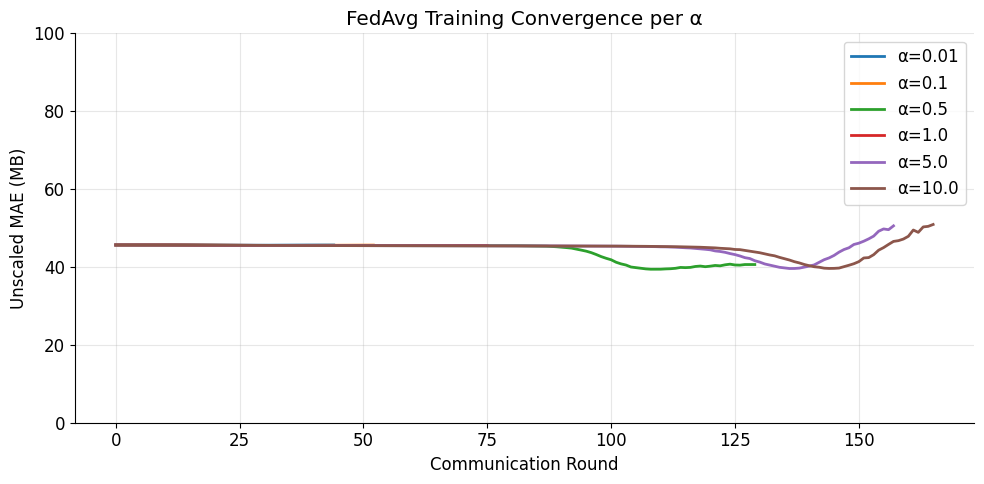

In [33]:
import matplotlib.pyplot as plt
uc2.setup_plot_style()

fig, ax = plt.subplots(figsize=(10, 5))
for alpha, r in sorted(results_fedavg.items()):
    glob_metrics = r["metrics"].get("glob_test_metric", [])
    maes = [m.get("unscaled_mae") for m in glob_metrics]
    ax.plot(maes, label=f"α={alpha}", linewidth=2)

ax.set_ylim(0, 100)
ax.set_xlabel("Communication Round")
ax.set_ylabel("Unscaled MAE (MB)")
ax.set_title("FedAvg Training Convergence per α")
ax.legend()
plt.tight_layout()
plt.show()

## Per-User Performance at Each α

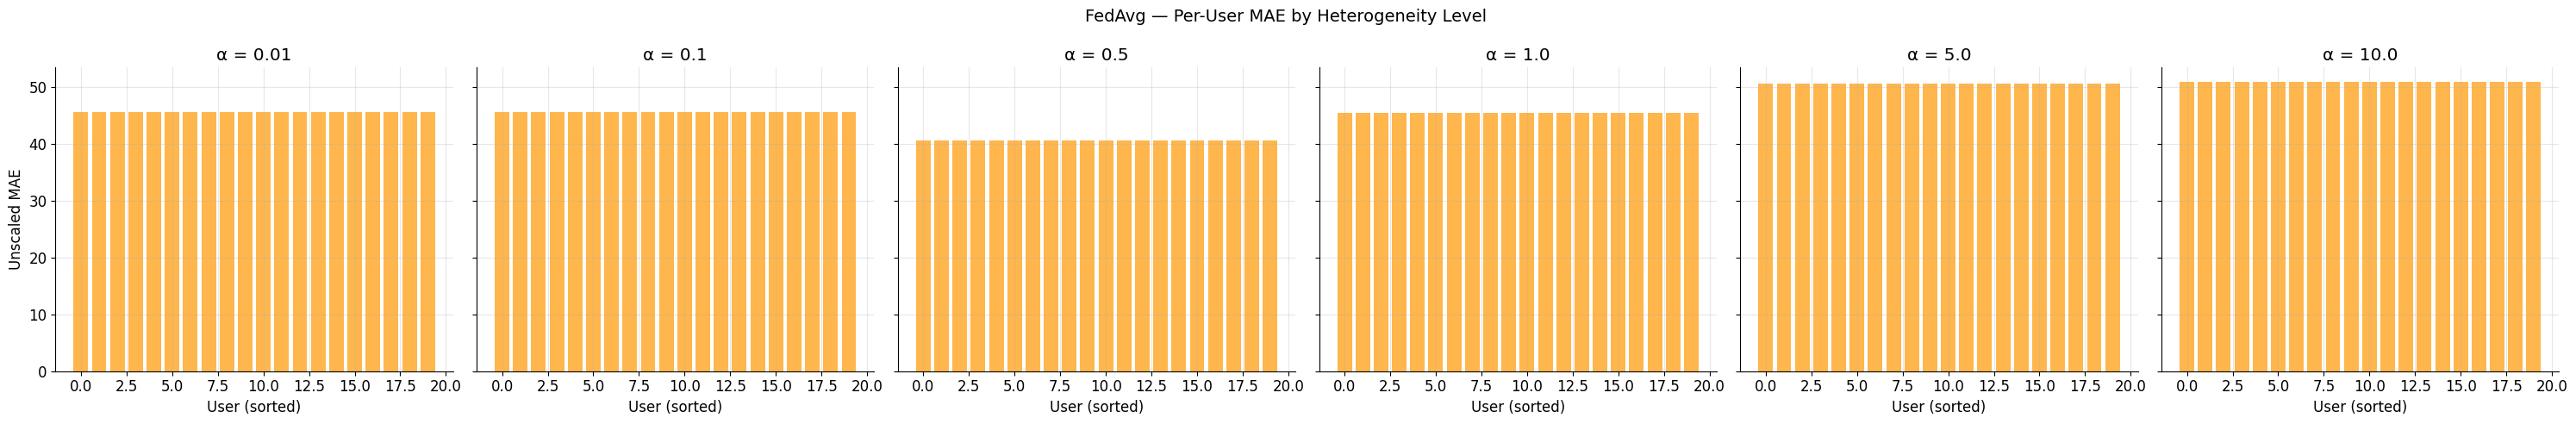

In [34]:
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(5*len(ALPHAS), 5), sharey=True)

for ax, alpha in zip(axes, ALPHAS):
    if alpha not in results_fedavg:
        continue
    r = results_fedavg[alpha]
    per_user_mae = r.get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
    if per_user_mae:
        ax.bar(range(len(per_user_mae)), sorted(per_user_mae, reverse=True),
               color=uc2.COLORS["FedAvg"], alpha=0.7)
    ax.set_title(f"α = {alpha}")
    ax.set_xlabel("User (sorted)")
    if ax == axes[0]:
        ax.set_ylabel("Unscaled MAE")

plt.suptitle("FedAvg — Per-User MAE by Heterogeneity Level", fontsize=14)
plt.tight_layout()
plt.show()

## Communication Cost

FedAvg: C = 2|θ| × R × |S| where |θ|=3.7MB, R=rounds, |S|=20

In [35]:
for alpha, r in sorted(results_fedavg.items()):
    n_rounds = r["n_rounds"]
    cost = uc2.comm_cost_fedavg(n_rounds, n_users_per_round=20)
    print(f"α={alpha}: {n_rounds} rounds → {cost:.1f} MB communication")

α=0.01: 45 rounds → 6660.0 MB communication
α=0.1: 53 rounds → 7844.0 MB communication
α=0.5: 130 rounds → 19240.0 MB communication
α=1.0: 76 rounds → 11248.0 MB communication
α=5.0: 158 rounds → 23384.0 MB communication
α=10.0: 166 rounds → 24568.0 MB communication


## Summary

FedAvg results saved to `results/fedavg/alpha_{α}/lstm/rep_0/`.
Key observations:
- Lower α (more heterogeneity) → higher MAE (expected)
- Full model exchange each round → high communication cost
- Per-user variance increases with heterogeneity

In [36]:
# ── Sanity-check: verify test partitions have no zero-sample users ──
import torch

LOOKBACK = 60
STEPS = 1

for alpha in ALPHAS:
    test_path = os.path.join(
        uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}",
        f"u20-alpha{alpha}-ratio1", "test", "test.pt"
    )
    data = torch.load(test_path, weights_only=False)
    samples = data["num_samples"]
    zeros = sum(1 for s in samples if s == 0)
    total = sum(samples)
    print(f"α={alpha:>5}: users={len(samples)}, "
          f"total_test={total}, min={min(samples)}, max={max(samples)}"
          + (f"  ⚠️ {zeros} ZEROS!" if zeros else "  ✓"))
    

α= 0.01: users=20, total_test=60000, min=3000, max=3000  ✓
α=  0.1: users=20, total_test=60000, min=3000, max=3000  ✓
α=  0.5: users=20, total_test=60000, min=3000, max=3000  ✓
α=  1.0: users=20, total_test=60000, min=3000, max=3000  ✓
α=  5.0: users=20, total_test=60000, min=3000, max=3000  ✓
α= 10.0: users=20, total_test=60000, min=3000, max=3000  ✓


In [37]:
# ── Post-training diagnostics ──
print(f"{'α':<8} {'Rounds':>6} {'EStop?':>6} {'BestRd':>6} "
      f"{'MAE':>10} {'MAPE':>10} {'PerUser μ':>10} {'PerUser σ':>10} {'#Users':>6}")
print("─" * 85)

for alpha in sorted(results_fedavg):
    r = results_fedavg[alpha]
    glob = r["metrics"]["glob_test_metric"]
    maes = [m.get("unscaled_mae", float("inf")) for m in glob]
    best_idx = int(np.argmin(maes))
    best = glob[best_idx]
    n_rounds = r["n_rounds"]
    early = "YES" if n_rounds < OVERRIDES["num_glob_iters"] else "no"

    per_user = r.get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
    n_users_with_metric = len(per_user) if per_user else 0
    pu_mean = np.mean(per_user) if per_user else float("nan")
    pu_std  = np.std(per_user)  if per_user else float("nan")

    print(f"{alpha:<8} {n_rounds:>6} {early:>6} {best_idx:>6} "
          f"{best.get('unscaled_mae', float('nan')):>10.3f} "
          f"{best.get('unscaled_mape', float('nan')):>10.4f} "
          f"{pu_mean:>10.3f} {pu_std:>10.3f} {n_users_with_metric:>6}")

# Flag suspicious patterns
for alpha in sorted(results_fedavg):
    r = results_fedavg[alpha]
    per_user = r.get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
    if per_user:
        if len(per_user) < 20:
            print(f"\n⚠️  α={alpha}: only {len(per_user)}/20 users have metrics!")
        if any(m == 0 for m in per_user):
            print(f"\n⚠️  α={alpha}: some users have MAE=0 (no test data?)")
        if max(per_user) > 10 * np.median(per_user):
            print(f"\n⚠️  α={alpha}: max MAE is >10× median — extreme outlier")

α        Rounds EStop? BestRd        MAE       MAPE  PerUser μ  PerUser σ #Users
─────────────────────────────────────────────────────────────────────────────────────
0.01         45    YES     23     45.575 366695874560.0000     45.646      0.000     20
0.1          53    YES     31     45.544 381076963328.0000     45.617      0.000     20
0.5         130    YES    108     39.419 2169735872512.0000     40.624      0.000     20
1.0          76    YES     54     45.502 188534685696.0000     45.509      0.000     20
5.0         158    YES    136     39.603 2431771738112.0000     50.557      0.000     20
10.0        166    YES    144     39.623 2477093289984.0000     50.911      0.000     20


In [38]:
print(f"{'α':<8} {'Best MAE':>10} {'Last MAE':>10} {'Best Rd':>8} {'P-user σ':>10}")
for alpha in sorted(results_fedavg):
    r = results_fedavg[alpha]
    glob = r["metrics"]["glob_test_metric"]
    maes = [m.get("unscaled_mae", float("inf")) for m in glob]
    per_user = r.get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
    print(f"{alpha:<8} {min(maes):>10.4f} {maes[-1]:>10.4f} "
          f"{int(np.argmin(maes)):>8} {np.std(per_user) if per_user else 0:>10.4f}")

α          Best MAE   Last MAE  Best Rd   P-user σ
0.01        45.5747    45.6456       23     0.0000
0.1         45.5443    45.6168       31     0.0000
0.5         39.4193    40.6242      108     0.0000
1.0         45.5025    45.5091       54     0.0000
5.0         39.6031    50.5572      136     0.0000
10.0        39.6231    50.9114      144     0.0000


In [39]:
import os, hashlib
import numpy as np
import torch

def gini(values):
    """Gini coefficient — 0 = perfect equality, 1 = max inequality."""
    v = np.array(values, dtype=float)
    if v.sum() == 0: return 0.0
    v = np.sort(v)
    n = len(v)
    cum = np.cumsum(v)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

# ── 1. Confirm partition files actually differ across α ──
print("=== Partition fingerprints ===")
fingerprints = {}
for alpha in ALPHAS:
    p = os.path.join(uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}",
                     f"u20-alpha{alpha}-ratio1", "train", "train.pt")
    data = torch.load(p, weights_only=False)
    # Hash full content of user 0's first 10 samples (catches both shuffle & assignment differences)
    sig = hashlib.md5(data["user_data"]["f_00000"]["x"][:10].numpy().tobytes()).hexdigest()[:12]
    fingerprints[alpha] = sig
    print(f"  α={alpha:>5}: user_0 fingerprint = {sig}, n_samples = {data['num_samples'][0]}")

print(f"\n{'⚠️  Identical files!' if len(set(fingerprints.values())) == 1 else '✓ Partitions differ'}")

# ── 2. Gini on sample distribution per α ──
print("\n=== Gini on train sample distribution per user ===")
print(f"{'α':<8} {'Gini':>8} {'min':>6} {'max':>6} {'max/min':>8}")
for alpha in ALPHAS:
    p = os.path.join(uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}",
                     f"u20-alpha{alpha}-ratio1", "train", "train.pt")
    data = torch.load(p, weights_only=False)
    s = data["num_samples"]
    print(f"{alpha:<8} {gini(s):>8.4f} {min(s):>6} {max(s):>6} {max(s)/min(s):>8.2f}")

# ── 3. Gini on y-distribution per user (proxy for AP heterogeneity) ──
# Different APs have different traffic patterns → different y stats per user
print("\n=== Per-user y-mean dispersion (proxy for AP heterogeneity) ===")
print(f"{'α':<8} {'y-mean Gini':>12} {'y-mean σ':>10} {'y-std σ':>10}")
for alpha in ALPHAS:
    p = os.path.join(uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}",
                     f"u20-alpha{alpha}-ratio1", "train", "train.pt")
    data = torch.load(p, weights_only=False)
    y_means, y_stds = [], []
    for uname in data["users"]:
        y = data["user_data"][uname]["y"].numpy().flatten()
        y_means.append(y.mean())
        y_stds.append(y.std())
    print(f"{alpha:<8} {gini(y_means):>12.4f} {np.std(y_means):>10.4f} {np.std(y_stds):>10.4f}")

# ── 4. Per-user MAE distribution (Gini on results) ──
print("\n=== Per-user MAE inequality (results) ===")
print(f"{'α':<8} {'MAE Gini':>10} {'min':>8} {'max':>8} {'σ':>8}")
for alpha in sorted(results_fedavg):
    per_user = results_fedavg[alpha].get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
    if per_user:
        print(f"{alpha:<8} {gini(per_user):>10.4f} {min(per_user):>8.4f} "
              f"{max(per_user):>8.4f} {np.std(per_user):>8.4f}")

=== Partition fingerprints ===
  α= 0.01: user_0 fingerprint = b600a5158dce, n_samples = 5539
  α=  0.1: user_0 fingerprint = 094930589209, n_samples = 4636
  α=  0.5: user_0 fingerprint = 3d01ae5407d9, n_samples = 4103
  α=  1.0: user_0 fingerprint = bf33d8d3a7e0, n_samples = 4778
  α=  5.0: user_0 fingerprint = a45cc31a5c73, n_samples = 4343
  α= 10.0: user_0 fingerprint = a45cc31a5c73, n_samples = 4543

✓ Partitions differ

=== Gini on train sample distribution per user ===
α            Gini    min    max  max/min
0.01       0.1239   2123   5676     2.67
0.1        0.0739   2858   5487     1.92
0.5        0.0382   3684   5181     1.41
1.0        0.0283   3594   4869     1.35
5.0        0.0194   4018   4690     1.17
10.0       0.0152   4036   4632     1.15

=== Per-user y-mean dispersion (proxy for AP heterogeneity) ===
α         y-mean Gini   y-mean σ    y-std σ
0.01           0.0299     0.0794     0.0217
0.1            0.0166     0.0469     0.0099
0.5            0.0107     0.0294  

In [40]:
import re, os
sa_path = os.path.join(uc2.LIB_DIR, "FLAlgorithms", "servers", "serveravg.py")
src = open(sa_path).read()
if "aggregate_parameters(partial=" not in src:
    src = src.replace(
        "self.aggregate_parameters()",
        "self.aggregate_parameters(partial=(self.mode != 'all'))")
    open(sa_path, "w").write(src)
    print("[patched] serveravg.py aggregation now respects partial mode")
else:
    print("[ok] already patched")

[ok] already patched


In [41]:
sb_path = os.path.join(uc2.LIB_DIR, "FLAlgorithms", "servers", "serverbase.py")
src = open(sb_path).read()
marker = "user.set_shared_parameters(self.model, mode=mode)"
if "mode='decode_fc2'" not in src and marker in src:
    src = src.replace(
        marker,
        "user.set_shared_parameters(self.model, mode='decode_fc2')")
    open(sb_path, "w").write(src)
    print("[patched] serverbase send now targets decode_fc2")
else:
    print("[ok] already patched or marker not found — check manually")

[ok] already patched or marker not found — check manually


In [ ]:
def _newpart_dataset_path():
    return os.path.join(uc2.DATA_PART, NEWPART_SUBDIR,   # set NEWPART_SUBDIR
                        f"lookback_{_NP_LOOKBACK}", f"steps_{_NP_STEPS}")